In [1]:
# imports
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

from helpers.sample import make_sample, stopping_time
from helpers.power import seq_power, std_power

In [ ]:
seq_powers = []
std_powers = []
N = 1000
theta = 0.1
alpha = 0.05
beta = 0.95
B = 5000

for _ in range(B):
  sample = make_sample(N, theta)
  seq_val, seq_reject, seq_st = seq_power(sample, alpha, beta)
  seq_powers.append((seq_val, seq_reject, seq_st))
  std_val, std_reject, std_st = std_power(sample, alpha)
  std_powers.append((std_val, std_reject, std_st))


In [118]:
seq_p = np.mean([reject for _, reject, _ in seq_powers])
seq_val_mean = np.mean([val for val, _, _ in seq_powers])
print(f"Sequential test power: {seq_p}")
print(f"Mean sequential test statistic: {seq_val_mean}")

std_p = np.mean([reject for _, reject in std_powers])
std_val_mean = np.mean([val for val, _ in std_powers])
print(f"Standard test power: {std_p}")
print(f"Mean standard test statistic: {std_val_mean}")

print(f"Difference in power: {std_p - seq_p}")

Sequential test power: 0.8858
Mean sequential test statistic: 0.9725026339697262
Standard test power: 0.9324
Mean standard test statistic: 3.1316458819011146
Difference in power: 0.046599999999999975


In [119]:
# among those who stopped early find average test statistic
seq_val_stopped_early = np.mean([val for val, _, st in seq_powers if st < N])
print(f"Average sequential test statistic among those who stopped early: {seq_val_stopped_early}")

Average sequential test statistic among those who stopped early: 0.9547543165216433


In [120]:
# calculate proportion of times sequential test stopped before N
stopping_times = [st for _, _, st in seq_powers]
prop_stopped_early = np.mean([st < N for st in stopping_times])
print(f"Proportion of times sequential test stopped before N: {prop_stopped_early}")

Proportion of times sequential test stopped before N: 0.9282


In [121]:
# find proportion that stopped at N and rejected the standard test
N_stop_reject = np.mean([(st == N and seq_reject == 1) for _, seq_reject, st in seq_powers])
print(f"Proportion that stopped at N and rejected the standard test: {N_stop_reject}")

Proportion that stopped at N and rejected the standard test: 0.0038


In [125]:
power_std_theoretical = scipy.stats.norm.cdf(theta * np.sqrt(N) - scipy.stats.norm.ppf(1-alpha))
print(f"Theoretical (with plugin) power of standard test: {power_std_theoretical}")

power_seq_theoretical = beta * prop_stopped_early + N_stop_reject
print(f"Theoretical (with plugin) power of sequential test: {power_seq_theoretical}")

power_diff_theoretical = power_std_theoretical - power_seq_theoretical
print(f"Theoretical difference in power: {power_diff_theoretical}")

power_diff_plugin = std_p - seq_val_stopped_early * prop_stopped_early - N_stop_reject
print(f"Plugin difference in power: {power_diff_plugin}")

Theoretical (with plugin) power of standard test: 0.9354201700477403
Theoretical (with plugin) power of sequential test: 0.88559
Theoretical difference in power: 0.04983017004774026
Plugin difference in power: 0.04239704340461062


## Power summaries

In [8]:
# load data/relative_gap_summary.csv
power_gap_summary = pd.read_csv(ROOT / "data/power_summary.csv")
print(power_gap_summary)

     theta      N  alpha  beta  seq_power  seq_stopping_time  std_power  \
0      0.0   1000   0.01  0.80      0.012            997.950      0.010   
1      0.0   1000   0.01  0.90      0.012            998.658      0.012   
2      0.0   1000   0.01  0.95      0.004            999.890      0.006   
3      0.0   1000   0.01  0.99      0.010            999.766      0.012   
4      0.0   1000   0.05  0.80      0.046            987.890      0.044   
..     ...    ...    ...   ...        ...                ...        ...   
155    1.0  50000   0.01  0.99      0.992           1036.518      1.000   
156    1.0  50000   0.05  0.80      0.806            555.832      1.000   
157    1.0  50000   0.05  0.90      0.900            652.514      1.000   
158    1.0  50000   0.05  0.95      0.962            733.254      1.000   
159    1.0  50000   0.05  0.99      0.992            884.602      1.000   

     std_stopping_time  seq_value_early_stop  seq_early_stop_prob  \
0               1000.0        

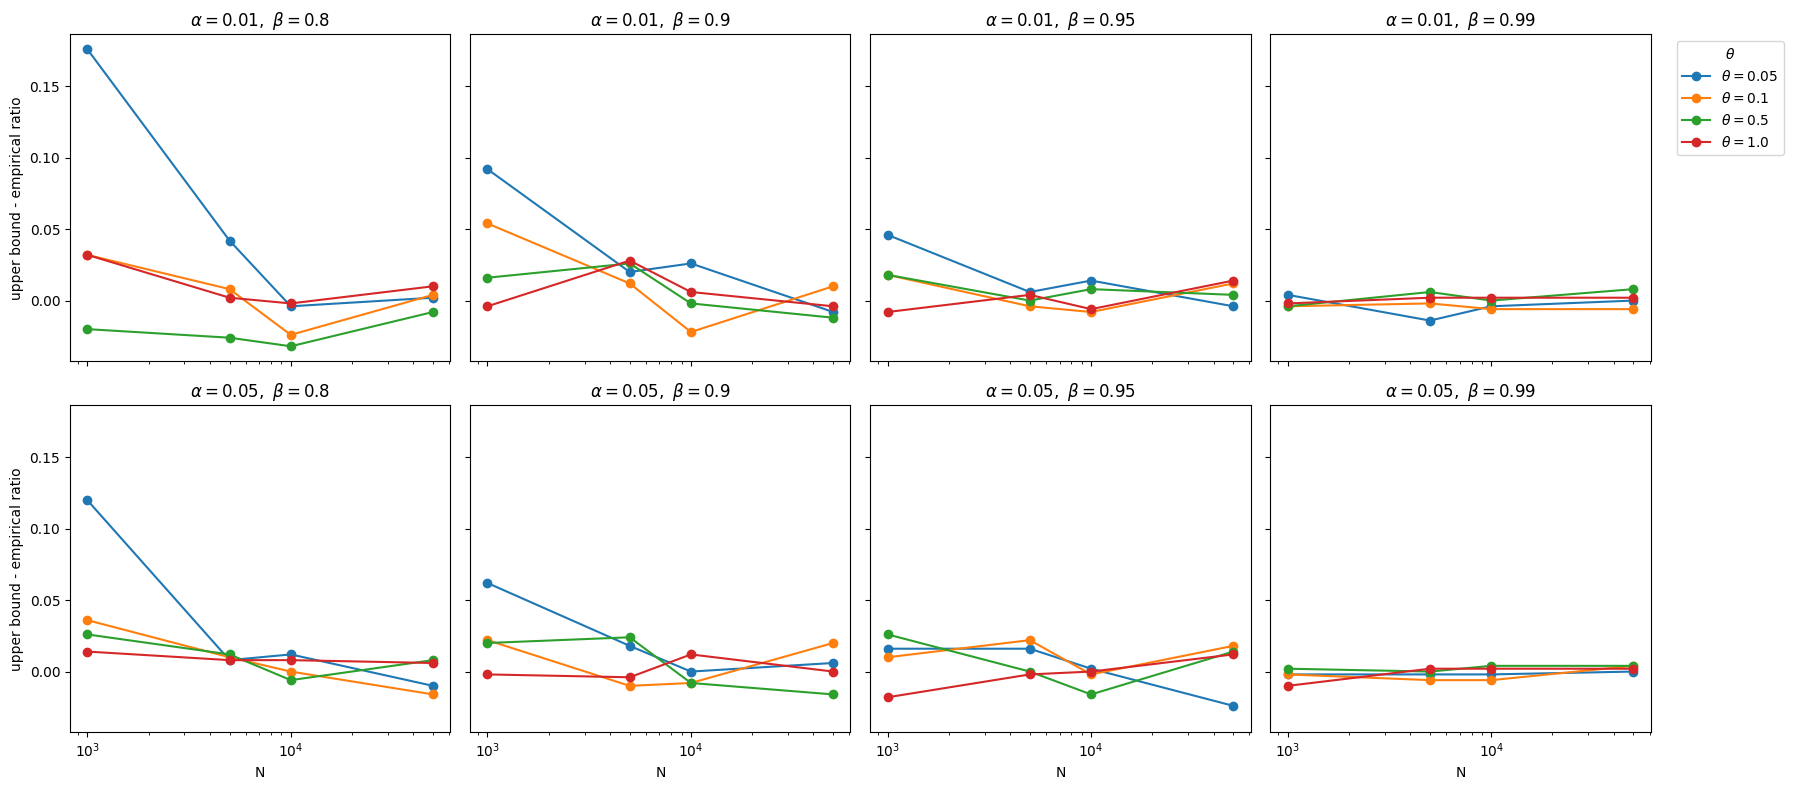

In [9]:
df = power_gap_summary.query("theta > 0").copy()

df["absolute_gap"] = (
    df["power_diff_up"]
    - df["power_diff"]
)

df = df.sort_values(["alpha", "beta", "theta", "N"])

alphas = sorted(df["alpha"].unique())
betas = sorted(df["beta"].unique())

fig, axes = plt.subplots(
    len(alphas),
    len(betas),
    figsize=(4.5 * len(betas), 4 * len(alphas)),
    sharex=True,
    sharey=True,
)

if len(alphas) == 1 and len(betas) == 1:
    axes = [[axes]]
elif len(alphas) == 1:
    axes = [axes]
elif len(betas) == 1:
    axes = [[ax] for ax in axes]

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        ax = axes[i][j]

        data_combo = df[
            (df["alpha"] == alpha)
            & (df["beta"] == beta)
        ]

        for theta, data_theta in data_combo.groupby("theta"):
            data_theta = data_theta.sort_values("N")

            ax.plot(
                data_theta["N"],
                data_theta["absolute_gap"],
                marker="o",
                label=fr"$\theta={theta}$",
            )

        ax.set_xscale("log")
        ax.set_title(fr"$\alpha={alpha},\ \beta={beta}$")

        if i == len(alphas) - 1:
            ax.set_xlabel("N")

        if j == 0:
            ax.set_ylabel("upper bound - empirical ratio")

        if i == 0 and j == len(betas) - 1:
            ax.legend(title=r"$\theta$", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    "../plots/power_ub.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()